In [89]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [90]:
# read in all the words
words = open("names.txt", 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(vocab_size)
# build the dataset
block_size = 3  # context length


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


import random

random.seed(42)
random.shuffle(words)
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

27
torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [91]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in **0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

    def clone(self):
        layer = Linear(self.weight.shape[0], self.weight.shape[1], self.bias is not None)
        layer.weight = self.weight.clone()
        if self.bias is not None:
            layer.bias = self.bias.clone()
        return layer

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True    # because during inference, we will not calculate gradients or update running mean/variance
        # parameters (trained with backprop)   (scale and shift)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim) # variance is std squared

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0, keepdim = True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

    def clone(self):
        bn = BatchNorm1d(self.gamma.shape[0], self.eps, self.momentum)
        bn.gamma = self.gamma.clone()
        bn.beta = self.beta.clone()
        bn.running_mean = self.running_mean.clone()
        bn.running_var = self.running_var.clone()
        return bn

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []



# Exercise 1

We look at initilizing the weights and biases to zero.

In [92]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g) * 0
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
]

for layer in layers:
    if isinstance(layer, Linear):
        layer.weight *= 0
        if layer.bias is not None:
            layer.bias *= 0



parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True


46497


In [93]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    #mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X, Y

    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: would take out retain_grad

    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break  # AFTER_DEBUG: would take out to run full optimization


      0/ 200000: 3.2958


layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

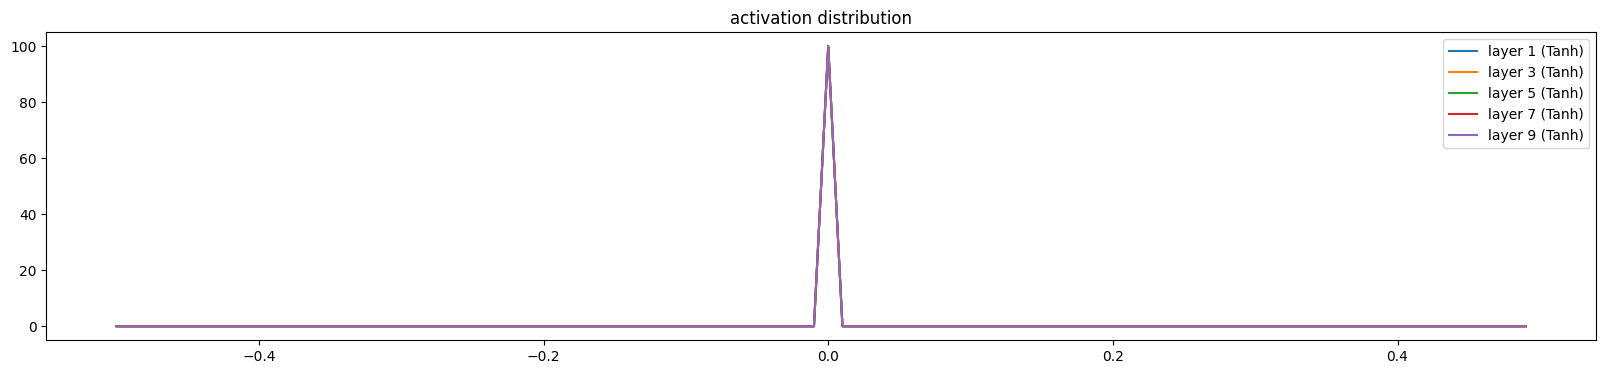

In [94]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print("layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%" % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.title('activation distribution')

From the mean and std statistics, we can see that the activations are all 0 despite training for 1000 steps. This indicates that the the gradients are probably not being passed down from the output layer.

layer 1 (      Tanh): mean +0.000000, std 0.000000e+00
layer 3 (      Tanh): mean +0.000000, std 0.000000e+00
layer 5 (      Tanh): mean +0.000000, std 0.000000e+00
layer 7 (      Tanh): mean +0.000000, std 0.000000e+00
layer 9 (      Tanh): mean +0.000000, std 0.000000e+00


Text(0.5, 1.0, 'gradient distribution (bar)')

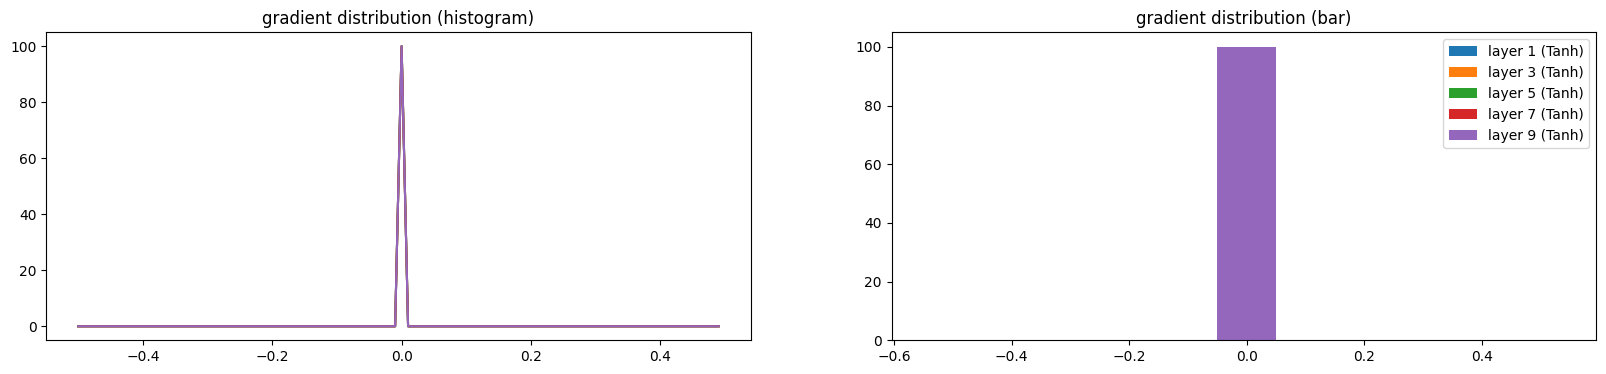

In [95]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s): mean %+f, std %e" % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density= True)
        plt.subplot(121)
        plt.plot(hx[:-1].detach(), hy.detach())

        # show as a bar chart
        plt.subplot(122)
        plt.bar(hx[:-1].detach(), hy.detach(), width=0.1)

        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends);
plt.subplot(121)
plt.title('gradient distribution (histogram)')

plt.subplot(122)
plt.title('gradient distribution (bar)')


In [96]:
for i, layer in enumerate(layers):
    if isinstance(layer, Linear):
        t = layer.out.grad
        print(t)

grads = set()
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Linear):
        t = layer.out.grad
        grads = grads.union(set(t.flatten().tolist()))

len(grads)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ...

1

Confirming our thoughts, we can see that all the layers of gradients except for the output layer have all the same gradient of 0.

weight   (27, 10) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight  (30, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight  (100, 27) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan


Text(0.5, 1.0, 'weights gradient distribution')

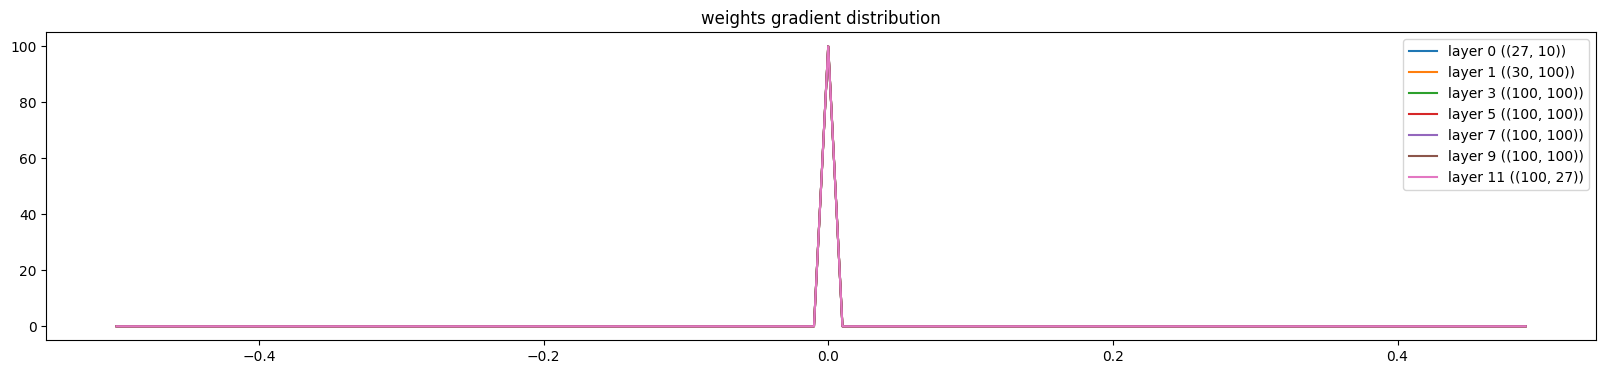

In [97]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print("weight %10s | mean %+f | std %e | grad:data ratio %e" % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density= True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({tuple(p.shape)})')

plt.legend(legends);
plt.title('weights gradient distribution')

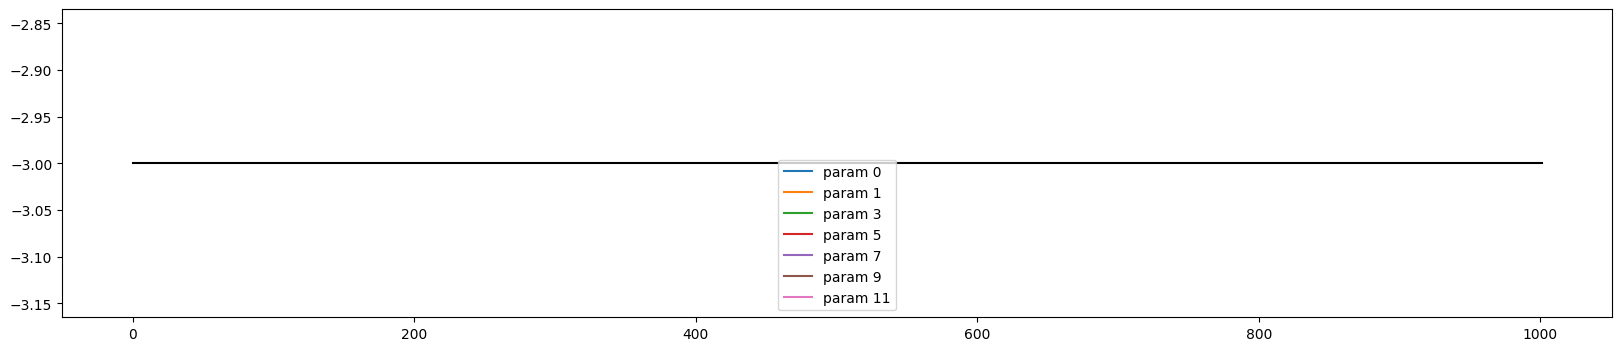

In [98]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)

plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [99]:
parameters

[tensor([[0., -0., -0., -0., 0., -0., -0., 0., 0., 0.],
         [-0., 0., -0., -0., 0., 0., 0., -0., 0., -0.],
         [0., -0., -0., 0., -0., 0., 0., -0., -0., 0.],
         [-0., 0., 0., 0., -0., -0., -0., 0., -0., 0.],
         [-0., -0., -0., 0., -0., 0., 0., 0., 0., -0.],
         [0., 0., 0., -0., 0., -0., 0., 0., -0., -0.],
         [0., -0., -0., -0., 0., -0., 0., 0., -0., 0.],
         [0., 0., -0., -0., -0., 0., 0., 0., -0., 0.],
         [-0., 0., -0., -0., 0., 0., 0., -0., -0., 0.],
         [-0., 0., 0., -0., -0., 0., -0., -0., -0., 0.],
         [-0., -0., -0., -0., -0., -0., -0., -0., -0., 0.],
         [-0., 0., 0., -0., -0., -0., -0., 0., 0., 0.],
         [-0., -0., -0., -0., -0., 0., -0., -0., 0., 0.],
         [-0., -0., -0., -0., 0., 0., 0., 0., 0., 0.],
         [0., -0., 0., -0., 0., 0., 0., -0., -0., -0.],
         [0., 0., -0., 0., 0., 0., 0., 0., -0., -0.],
         [-0., 0., 0., 0., 0., -0., 0., 0., -0., -0.],
         [0., 0., 0., 0., -0., -0., -0., 0., 0.

Only the last layer is trained.

We note that $\tanh(0) = 0$

If all neurons are set to $0$, then when $\tanh(W\cdot x) + b$ is computed, since $W=0, b=0$, they won't contributing to the output.
   - During backpropagation, gradients w.r.t. hidden parameters rely on `(∂Loss/∂Out) * (∂Out/∂h) * (∂h/∂W)`, but since `h=0` for all inputs and all layers, `∂h/∂W=0` (the partial derivatives vanish).
   - Hence, internal weights do not get meaningful updates—only the final layer (which directly produces the predicted logits) sees a non-zero gradient from the loss.

Symmetry: Since all the neurons and the weights are the same, when a gradient is backpropagated from the output layer, it will be back propagated the same for all layers, so the network would not be able to break this symmetry.

   - The model effectively becomes a constant predictor: only the last layer can adapt slightly, while earlier layers remain “stuck.”
This explains why only the output layer’s parameters are changing, while earlier parameters remain at zero.

Question: if only a row of a linear layer is 0, then would we have no learning within this row? i'm thinking yes because it would mean that this row takes no contribution from any of the input features.


**Explanation (Exercise 1)**

Initializing all parameters (weights and biases) to zero in a neural network leads to several critical issues that prevent the model from training effectively. Here is a rigorous mathematical explanation of why this occurs:

1. **Uniform Hidden Activations**

    - **Forward Pass Computation:**
      Each neuron in a hidden layer computes its activation as:
      \[
      h = W \cdot x + b
      \]
      where:
      - \( W \) is the weight matrix.
      - \( x \) is the input vector.
      - \( b \) is the bias vector.
      
      With \( W = 0 \) and \( b = 0 \), this simplifies to:
      \[
      h = 0 \cdot x + 0 = 0
      \]
      
    - **Implications:**
      - Every neuron in the hidden layer outputs the same value (zero) regardless of the input.
      - This leads to identical activation patterns across all neurons in the layer.
      - Consequently, the subsequent layers receive identical inputs, eliminating any feature diversity that is essential for learning.

2. **Zero Gradients in Hidden Layers**

    - **Backward Pass Computation:**
      The gradient of the loss \( \mathcal{L} \) with respect to the weights \( W \) in a hidden layer is given by:
      \[
      \frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial h} \cdot \frac{\partial h}{\partial W}
      \]
      
      Given \( h = W \cdot x + b \), we have:
      \[
      \frac{\partial h}{\partial W} = x
      \]
      
      However, since \( h = 0 \) during the forward pass, the activation output does not depend on the weights or biases, making:
      \[
      \frac{\partial h}{\partial W} = x = 0 \quad \text{(since } h \text{ is zero regardless of } x\text{)}
      \]
      
    - **Resulting Gradients:**
      \[
      \frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial h} \cdot 0 = 0
      \]
      
      - All gradients with respect to the weights in hidden layers become zero.
      - As a result, there's no gradient signal to update the weights during optimization.
      - Only the weights in the output layer receive non-zero gradients, allowing them to update based on the loss.

3. **Symmetry and Lack of Parameter Diversity**

    - **Symmetrical Weights:**
      - With all weights initialized to zero, neurons in the same layer are symmetric.
      - Each neuron performs identical computations and receives identical gradients.
      
    - **No Breaking of Symmetry:**
      - Gradient updates depend on the current weights and are the same for all symmetric neurons.
      - Without initial diversity in weights, all neurons remain identical throughout training.
      - This prevents the network from learning diverse features, effectively reducing the network's capacity.

4. **Effect on Learning Dynamics**

    - **Stagnant Hidden Layers:**
      - Since hidden layers do not learn (their weights do not update), they cannot capture meaningful patterns or representations.
      - The network's expressiveness is severely limited to the capabilities of the output layer alone.
      
    - **Output Layer Dominance:**
      - Only the output layer adapts during training, which might lead to minimal improvements.
      - The lack of meaningful hidden representations hinders the network’s ability to generalize or perform complex tasks.
      
    - **Vanishing Gradient Problem:**
      - Although not the classic vanishing gradient issue, initializing weights to zero exacerbates gradient flow problems.
      - Gradients do not propagate effectively through the network, stalling learning processes.

5. **Mathematical Confirmation**

    - **Jacobian Matrix Analysis:**
      Consider the Jacobian matrix \( J \) of the network, representing the partial derivatives of each layer's outputs with respect to its inputs.
      
      With zero-initialized weights:
      \[
      J = \frac{\partial h}{\partial x} = W = 0
      \]
      
      - The zero Jacobian implies that small changes in the input \( x \) do not affect the output \( h \).
      - This lack of sensitivity means the network cannot adjust its outputs to minimize the loss effectively.
      
    - **Loss Function Gradient:**
      For a loss function \( \mathcal{L} \), the gradient with respect to the hidden layer’s outputs is:
      \[
      \frac{\partial \mathcal{L}}{\partial h} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial h}
      \]
      
      - Since \( h = 0 \), and assuming \( \frac{\partial \hat{y}}{\partial h} = 0 \) due to no influence of \( h \) on \( \hat{y} \), the gradient \( \frac{\partial \mathcal{L}}{\partial h} = 0 \).
      - This results in no gradient flow back through the network, preventing weight updates in hidden layers.

6. **Conclusion**

    Initializing all network parameters to zero creates a scenario where:

    - **Identical Neuron Behavior:** All neurons produce the same output, eliminating the network's ability to learn diverse features.
    - **No Gradient Flow:** Gradients in hidden layers are zero, preventing weight updates and learning.
    - **Symmetry Preservation:** Lack of weight diversity hinders the network's capacity to break symmetry and learn effectively.

    To facilitate effective training, it is essential to initialize weights with small random values. This breaks symmetry, ensures diverse neuron activations, and allows gradients to propagate correctly through the network, enabling meaningful learning.



**Explanation (Exercise 1)**

When all parameters (weights and biases) are initialized to zero:

1. **Uniform hidden activations**
   - Each hidden layer computes `h = W·x + b`. With `W = 0` and `b = 0`, every neuron’s output is `0` for any input `x`.
   - Consequently, each hidden layer’s output is the same constant (zero), so the next layer sees only zeros.

2. **Zero gradients in hidden layers**
   - During backpropagation, gradients w.r.t. hidden parameters rely on `(∂Loss/∂Out) * (∂Out/∂h) * (∂h/∂W)`, but since `h=0` for all inputs and all layers, `∂h/∂W=0` (the partial derivatives vanish).
   - Hence, internal weights do not get meaningful updates—only the final layer (which directly produces the predicted logits) sees a non-zero gradient from the loss.

3. **Symmetry and no signal**
   - All neurons in a hidden layer have identical conditions, so their updates become identical or zero; the network can’t break this symmetry if everything is initialized the same.

4. **Effect on training**
   - The model effectively becomes a constant predictor: only the last layer can adapt slightly, while earlier layers remain “stuck.”
   - Breaking this requires non-zero initialization, otherwise the chain rule never carries differing gradients back to the hidden layers.

This explains why only the output layer’s parameters are changing, while earlier parameters remain at zero.

In [100]:
"""
Yes, zero-initializing all weights still keeps hidden outputs constant,
so gradients remain zero even if the nonlinearity doesn't map 0 to 0.
The core issue is the identical initial weights, not just the activation function.
"""

"\nYes, zero-initializing all weights still keeps hidden outputs constant,\nso gradients remain zero even if the nonlinearity doesn't map 0 to 0.\nThe core issue is the identical initial weights, not just the activation function.\n"

# Exercise 2

Training a batch norm and folding the weights


In [101]:
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 100  # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1 # Gamma is the scale of the Batch Norm
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True


47024


In [102]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update to data ratio

for i in range(max_steps):

    #mini batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator = g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad

    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # calculating update to data ratio


      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1042
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2264
  60000/ 200000: 1.7339
  70000/ 200000: 2.1746
  80000/ 200000: 2.1895
  90000/ 200000: 1.8282
 100000/ 200000: 2.3641
 110000/ 200000: 2.2021
 120000/ 200000: 2.1036
 130000/ 200000: 1.8565
 140000/ 200000: 1.8050
 150000/ 200000: 1.9258
 160000/ 200000: 1.8759
 170000/ 200000: 1.8332
 180000/ 200000: 2.2319
 190000/ 200000: 2.0518


In [103]:
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

In [108]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # concat into (N, block_size*n_embd)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.0123226642608643
val 2.0840728282928467
test 2.084648370742798


In [109]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():
    for _ in range(20):
        out = []
        context = [0]*block_size # initialize with ...
        while True:
            # forward pass into the neural net
            emb = C[torch.tensor([context])] # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # (1, block_size*n_embd)
            for layer in layers:
                x = layer(x)

            probs = F.softmax(x, dim=1)
            # sample from the distribution
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            # shift the context window and track the samples
            context = context[1:] + [ix]
            out.append(ix)

            # if we sample the special '.' token, break
            if ix == 0:
                break

        print(''.join(itos[i] for i in out)) # convert indices back to characters


mona.
kmyah.
see.
madhayla.
reisra.
ejdra.
gradee.
daelin.
shyloni.
eden.
est.
aarielle.
malaia.
noshubergiaghan.
trick.
welle.
jose.
cayu.
zayven.
kylene.


The way batch norm works is by standardizing the inputs and adding a scale and shift.

If the inputs are $X$ (with mean $\mu$ and $\sigma$ variance), the linear layer is $A$, and BatchNorm parameters of $\gamma$ scale and $\beta$ shift, we have:
$$
\begin{align*}
\mathrm{BatchNorm}(\mathrm{Linear}(X)) &= \gamma \left(\frac{AX-\mu}{\sigma}\right) + \beta\\
&= \frac{\gamma A}{\sigma} X - \frac{\gamma \mu}{\sigma} + \beta\\
\end{align*}
$$
so we essentially have a linear layer of: $A' = \frac{\gamma A}{\sigma}$ and $B' = -\frac{\gamma \mu}{\sigma} + \beta$.

In [110]:
new_layer_merged = []
with torch.no_grad():
    for layer in layers:
        if isinstance(layer, Linear):
            # clone layer
            new_layer_merged.append(layer.clone())
        elif isinstance(layer, BatchNorm1d):
            # modify previous layer
            prev_layer = new_layer_merged[-1]
            prev_layer.bias = layer.beta - layer.gamma * layer.running_mean / torch.sqrt(layer.running_var + layer.eps)
            prev_layer.weight = prev_layer.weight * layer.gamma / torch.sqrt(layer.running_var + layer.eps)
        elif isinstance(layer, Tanh):
            new_layer_merged.append(Tanh())

In [112]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # concat into (N, block_size*n_embd)
    for layer in new_layer_merged:
        x = layer(x)

    loss = F.cross_entropy(x, y)
    print(split, loss.item())


split_loss('train')
split_loss('val')
split_loss('test')



train 2.0123226642608643
val 2.0840728282928467
test 2.084648609161377


In [113]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():
    for _ in range(20):
        out = []
        context = [0]*block_size # initialize with ...
        while True:
            # forward pass into the neural net
            emb = C[torch.tensor([context])] # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # (1, block_size*n_embd)
            for layer in new_layer_merged:
                x = layer(x)

            probs = F.softmax(x, dim=1)
            # sample from the distribution
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            # shift the context window and track the samples
            context = context[1:] + [ix]
            out.append(ix)

            # if we sample the special '.' token, break
            if ix == 0:
                break

        print(''.join(itos[i] for i in out)) # convert indices back to characters


mona.
kmyah.
see.
madhayla.
reisra.
ejdra.
gradee.
daelin.
shyloni.
eden.
est.
aarielle.
malaia.
noshubergiaghan.
trick.
welle.
jose.
cayu.
zayven.
kylene.
